# Modelo Predictivo: Interacciones en Redes Sociales → Resultado Electoral

## Objetivo
Construir un modelo que prediga el **porcentaje de votación** de cada candidato a partir de sus **indicadores de interacción en redes sociales** (panel reconstruido de 14 días).

## Enfoque Metodológico
- **Y (target)**: % de votos del candidato respecto al total de votos de candidatos *trazados* (con publicaciones activas) en su ciudad.
- **X (features)**: Indicadores agregados de interacciones por candidato (sumados sobre todas sus publicaciones).
- **Exclusión**: Piedecuesta (ganador destituido, eliminó redes).
- **Arquitectura**: Problema de regresión tabular (NO serie de tiempo). Se evalúan múltiples modelos incluyendo MLP con PyTorch.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

import torch
import torch.nn as nn
import torch.optim as optim

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 5)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print('✓ Librerías cargadas')


✓ Librerías cargadas


## 1. Carga de Datos

In [9]:
# Panel reconstruido
panel = pd.read_csv('panel_historico_reconstruido.csv')

# Resultados electorales
elec = pd.read_excel('../Colombia/Resultados electorales.xlsx')

print(f'Panel: {len(panel):,} publicaciones, {panel["id_candidato"].nunique()} candidatos')
print(f'Electoral: {len(elec)} candidatos en {elec["Municipio"].nunique()} ciudades')
print(f'Columnas electorales: {elec.columns.tolist()}')
elec.head(3)


Panel: 5,776 publicaciones, 123 candidatos
Electoral: 350 candidatos en 33 ciudades
Columnas electorales: ['ID Candidato', 'Municipio', 'Departamento', 'DIVIPOLA', 'Cód', 'Candidato', 'Partido / Movimiento Político', 'Votos', 'Ganador']


,ID Candidato,Municipio,Departamento,DIVIPOLA,Cód,Candidato,Partido / Movimiento Político,Votos,Ganador
0,COL-05045-001,Apartadó,Antioquia,5045,1,Adolfo Leon Tabares Gutierrez,Movimiento Salvación Nacional,1238,No
1,COL-05045-002,Apartadó,Antioquia,5045,2,Luis Gonzalo Giraldo Aguirre,Agrupación Política en Marcha,146,No
2,COL-05045-003,Apartadó,Antioquia,5045,3,John Jaime Urrea Chica,Partido Colombia Justa Libres,541,No


## 2. Estadísticas Descriptivas del Universo Electoral

In [10]:
# --- Exclusión de Piedecuesta ---
# Excluir Piedecuesta (ganador destituido) y Bogota D.C. (Gustavo Bolivar es influencer outlier)
EXCLUIR_MUNICIPIOS = ['Piedecuesta', 'Barrancabermeja','Bogotá D.C.']
elec_clean = elec[~elec['Municipio'].isin(EXCLUIR_MUNICIPIOS)].copy()
n_excl = len(elec) - len(elec_clean)
print(f'Candidatos tras excluir {EXCLUIR_MUNICIPIOS}: {len(elec_clean)} (eliminados: {n_excl})')

# IDs con publicaciones activas en el panel
panel_ids = set(panel['id_candidato'].unique())

# Marcar candidatos activos
elec_clean['tiene_publicaciones'] = elec_clean['ID Candidato'].isin(panel_ids)

# --- Redes por candidato ---
# Saber qué redes tiene cada candidato activo
redes_por_candidato = panel.groupby('id_candidato')['platform'].apply(lambda x: set(x.unique())).to_dict()
elec_clean['redes_activas'] = elec_clean['ID Candidato'].map(redes_por_candidato)
elec_clean['tiene_facebook'] = elec_clean['redes_activas'].apply(lambda x: 'Facebook' in x if isinstance(x, set) else False)
elec_clean['tiene_tiktok'] = elec_clean['redes_activas'].apply(lambda x: 'TikTok' in x if isinstance(x, set) else False)
elec_clean['tiene_twitter'] = elec_clean['redes_activas'].apply(lambda x: 'Twitter' in x if isinstance(x, set) else False)
elec_clean['n_redes'] = elec_clean['redes_activas'].apply(lambda x: len(x) if isinstance(x, set) else 0)

# --- Estadísticas ---
n_total = len(elec_clean)
n_ciudades = elec_clean['Municipio'].nunique()
n_10k = (elec_clean['Votos'] >= 10000).sum()
n_activos = elec_clean['tiene_publicaciones'].sum()

print(f'\n=== UNIVERSO ELECTORAL (sin Piedecuesta) ===')
print(f'Candidatos totales: {n_total}')
print(f'Ciudades: {n_ciudades}')
print(f'Candidatos con ≥ 10,000 votos: {n_10k}')
print(f'Candidatos con publicaciones activas: {n_activos} ({n_activos/n_total*100:.1f}%)')

# Candidatos activos por red
for red in ['facebook', 'tiktok', 'twitter']:
    col = f'tiene_{red}'
    n = elec_clean[col].sum()
    print(f'  Con {red.title()} activo: {n} ({n/n_total*100:.1f}% del total, {n/n_activos*100:.1f}% de activos)')

# Candidatos con >= 10,000 votos que son activos
activos_10k = elec_clean[(elec_clean['Votos'] >= 10000) & (elec_clean['tiene_publicaciones'])]
print(f'\nCandidatos ≥ 10k votos Y activos: {len(activos_10k)} de {n_10k} ({len(activos_10k)/max(n_10k,1)*100:.1f}%)')
for red in ['facebook', 'tiktok', 'twitter']:
    col = f'tiene_{red}'
    n = activos_10k[col].sum()
    print(f'  Con {red.title()}: {n} ({n/max(len(activos_10k),1)*100:.1f}%)')

# Número de redes
print(f'\nDistribución de # de redes entre candidatos activos:')
print(elec_clean[elec_clean['tiene_publicaciones']]['n_redes'].value_counts().sort_index().to_string())


Candidatos tras excluir ['Piedecuesta', 'Barrancabermeja', 'Bogotá D.C.']: 316 (eliminados: 34)

=== UNIVERSO ELECTORAL (sin Piedecuesta) ===
Candidatos totales: 316
Ciudades: 30
Candidatos con ≥ 10,000 votos: 118
Candidatos con publicaciones activas: 109 (34.5%)
  Con Facebook activo: 95 (30.1% del total, 87.2% de activos)
  Con Tiktok activo: 74 (23.4% del total, 67.9% de activos)
  Con Twitter activo: 67 (21.2% del total, 61.5% de activos)

Candidatos ≥ 10k votos Y activos: 109 de 118 (92.4%)
  Con Facebook: 95 (87.2%)
  Con Tiktok: 74 (67.9%)
  Con Twitter: 67 (61.5%)

Distribución de # de redes entre candidatos activos:
n_redes
1    27
2    37
3    45


## 3. Construcción de la Variable Objetivo (Y)

El **Y** es el porcentaje de votación del candidato, donde el denominador es la **suma de votos de los candidatos trazados** (con publicaciones activas) en esa misma ciudad.

Candidatos trazados: 109
Ciudades con candidatos trazados: 30

Distribución del % de votos (trazados):
count    109.00
mean      27.52
std       20.11
min        1.25
25%       10.29
50%       28.82
75%       40.93
max       85.26


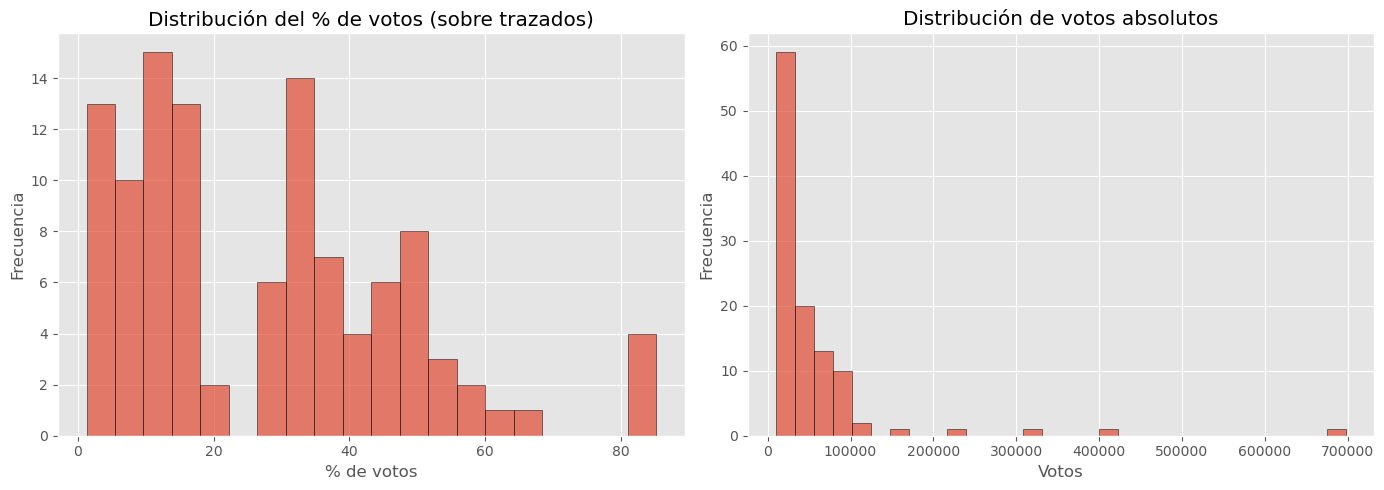

,ID Candidato,Municipio,Candidato,Votos,pct_votos_trazados,n_redes
3,COL-05045-004,Apartadó,Hector Rangel Palacios Rodriguez,28317,56.401625,2
4,COL-05045-005,Apartadó,Adolfo David Romero Benitez,21889,43.598375,1
13,COL-63001-003,Armenia,Stefany Gomez Murillo,11674,15.762044,2
23,COL-63001-013,Armenia,James Padilla Garcia,35703,48.205606,1
24,COL-63001-014,Armenia,Jose Ignacio Rojas Sepulveda,26687,36.032350,1
38,COL-08001-002,Barranquilla,Alejandro Char Chaljub,417644,85.261310,3
41,COL-08001-005,Barranquilla,Antonio Eduardo Bohorquez Collazos,53144,10.849257,1
42,COL-08001-006,Barranquilla,Hassan Fares Hachem,19052,3.889433,1
43,COL-05049-001,Bello,Juan Felipe Restrepo Tamayo,11226,8.512090,1
45,COL-05049-003,Bello,Yulieth Lorena Gonzalez Ospina,64022,48.544543,3


In [11]:
# Solo candidatos con publicaciones activas
df_target = elec_clean[elec_clean['tiene_publicaciones']].copy()

# Calcular el total de votos de candidatos trazados por ciudad
votos_trazados_por_ciudad = df_target.groupby('Municipio')['Votos'].transform('sum')
df_target['pct_votos_trazados'] = (df_target['Votos'] / votos_trazados_por_ciudad) * 100

print(f'Candidatos trazados: {len(df_target)}')
print(f'Ciudades con candidatos trazados: {df_target["Municipio"].nunique()}')
print(f'\nDistribución del % de votos (trazados):')
print(df_target['pct_votos_trazados'].describe().round(2).to_string())

# Histograma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_target['pct_votos_trazados'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución del % de votos (sobre trazados)')
axes[0].set_xlabel('% de votos')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df_target['Votos'], bins=30, edgecolor='black', alpha=0.7)
axes[1].set_title('Distribución de votos absolutos')
axes[1].set_xlabel('Votos')
axes[1].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

df_target[['ID Candidato', 'Municipio', 'Candidato', 'Votos', 'pct_votos_trazados', 'n_redes']].head(10)


## 4. Construcción del Dataset de Features (X)

Agregamos las interacciones a nivel de candidato. Para cada candidato sumamos todas sus publicaciones. Generamos features separados por plataforma y totales.

In [12]:
# Columnas de interacción en el panel
interaction_types = ['likes', 'comentarios', 'compartidos', 'vistas', 'favoritos',
                     'fb_love', 'fb_haha', 'fb_care', 'fb_wow', 'fb_sad', 'fb_angry']
DIAS = list(range(15))

# --- Features por candidato ---
features_list = []

for cand_id in df_target['ID Candidato'].unique():
    cand_posts = panel[panel['id_candidato'] == cand_id]
    row = {'id_candidato': cand_id}
    
    # Número de publicaciones totales y por plataforma
    row['n_posts_total'] = len(cand_posts)
    for plat in ['Facebook', 'TikTok', 'Twitter']:
        plat_posts = cand_posts[cand_posts['platform'] == plat]
        row[f'n_posts_{plat.lower()}'] = len(plat_posts)
        
        # Para cada tipo de interacción: total acumulado d14 y crecimiento (d14-d3)
        for itype in interaction_types:
            col_d14 = f'{itype}_acum_d14'
            col_d3 = f'{itype}_acum_d3'
            
            if col_d14 in plat_posts.columns:
                total = plat_posts[col_d14].sum()
                row[f'{plat.lower()}_{itype}_total'] = total
                
                # Ratio de crecimiento tardío (d14 vs d3)
                d3_sum = plat_posts[col_d3].sum() if col_d3 in plat_posts.columns else 0
                row[f'{plat.lower()}_{itype}_late_growth'] = (total - d3_sum) if d3_sum > 0 else 0
    
    # Totales cross-platform
    for itype in interaction_types:
        col_d14 = f'{itype}_acum_d14'
        if col_d14 in cand_posts.columns:
            row[f'total_{itype}'] = cand_posts[col_d14].sum()
    
    # Promedios por post
    row['avg_interactions_per_post'] = cand_posts['total_interacciones'].mean() if len(cand_posts) > 0 else 0
    row['max_interactions_single_post'] = cand_posts['total_interacciones'].max() if len(cand_posts) > 0 else 0
    row['std_interactions'] = cand_posts['total_interacciones'].std() if len(cand_posts) > 1 else 0
    
    features_list.append(row)

df_features = pd.DataFrame(features_list)
df_features = df_features.fillna(0)

print(f'Features matrix: {df_features.shape[0]} candidatos × {df_features.shape[1]} columnas')
print(f'\nColumnas generadas ({df_features.shape[1]}):')
for i, col in enumerate(df_features.columns):
    print(f'  {i+1}. {col}')


Features matrix: 109 candidatos × 85 columnas

Columnas generadas (85):
  1. id_candidato
  2. n_posts_total
  3. n_posts_facebook
  4. facebook_likes_total
  5. facebook_likes_late_growth
  6. facebook_comentarios_total
  7. facebook_comentarios_late_growth
  8. facebook_compartidos_total
  9. facebook_compartidos_late_growth
  10. facebook_vistas_total
  11. facebook_vistas_late_growth
  12. facebook_favoritos_total
  13. facebook_favoritos_late_growth
  14. facebook_fb_love_total
  15. facebook_fb_love_late_growth
  16. facebook_fb_haha_total
  17. facebook_fb_haha_late_growth
  18. facebook_fb_care_total
  19. facebook_fb_care_late_growth
  20. facebook_fb_wow_total
  21. facebook_fb_wow_late_growth
  22. facebook_fb_sad_total
  23. facebook_fb_sad_late_growth
  24. facebook_fb_angry_total
  25. facebook_fb_angry_late_growth
  26. n_posts_tiktok
  27. tiktok_likes_total
  28. tiktok_likes_late_growth
  29. tiktok_comentarios_total
  30. tiktok_comentarios_late_growth
  31. tiktok_c

## 5. Dataset Final para Entrenamiento

In [13]:
# Merge features con target
df_model = df_target[['ID Candidato', 'Municipio', 'Candidato', 'Votos', 
                       'pct_votos_trazados', 'Ganador']].merge(
    df_features, left_on='ID Candidato', right_on='id_candidato', how='inner'
).drop(columns=['id_candidato'])

# Separar X e Y
exclude_cols = ['ID Candidato', 'Municipio', 'Candidato', 'Votos', 'pct_votos_trazados', 'Ganador']
feature_cols = [c for c in df_model.columns if c not in exclude_cols]

X = df_model[feature_cols].values.astype(np.float64)
y = df_model['pct_votos_trazados'].values.astype(np.float64)

print(f'Dataset final: {X.shape[0]} candidatos × {X.shape[1]} features')
print(f'Target (Y): mean={y.mean():.2f}%, std={y.std():.2f}%, min={y.min():.2f}%, max={y.max():.2f}%')
print(f'\nGuardando dataset...')
df_model.to_csv('dataset_modelo_electoral.csv', index=False)
print('✓ Guardado en dataset_modelo_electoral.csv')


Dataset final: 109 candidatos × 84 features
Target (Y): mean=27.52%, std=20.02%, min=1.25%, max=85.26%

Guardando dataset...
✓ Guardado en dataset_modelo_electoral.csv


## 6. Comparación de Modelos (Leave-One-Out Cross-Validation)

Dado el tamaño pequeño del dataset (~120 candidatos), usamos **Leave-One-Out CV** para maximizar los datos de entrenamiento en cada fold.

### ¿Por qué NO es una serie de tiempo?
Solo tenemos **un Y** por candidato (el resultado electoral final). Las interacciones día a día son features que describen *cómo creció la popularidad*, no una serie temporal a predecir. Por lo tanto, **aplanamos** los 14 días en columnas (como ya hicimos) y tratamos esto como regresión tabular clásica.

### ¿Por qué NO softmax?
Softmax normaliza las probabilidades de múltiples clases para que sumen 1. Nuestro Y ya está expresado como %, pero **cada candidato se predice independientemente** (no necesitamos que las predicciones de los candidatos de una misma ciudad sumen 100%). El modelo aprende a predecir el % directamente como regresión.

In [14]:
# Escalar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Modelos a comparar ---
models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
    'SVR (RBF)': SVR(kernel='rbf', C=10, epsilon=0.5),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=5, random_state=SEED),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3, 
                                                    learning_rate=0.05, random_state=SEED),
    'MLP (sklearn)': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000, 
                                   learning_rate='adaptive', random_state=SEED, 
                                   early_stopping=True, validation_fraction=0.15),
}

loo = LeaveOneOut()
results = {}

print('Evaluando modelos con Leave-One-Out CV...')
print(f'({X_scaled.shape[0]} folds, cada uno entrena con {X_scaled.shape[0]-1} muestras)\n')

for name, model in models.items():
    try:
        y_pred = cross_val_predict(model, X_scaled, y, cv=loo)
        
        mae = mean_absolute_error(y, y_pred)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        r2 = r2_score(y, y_pred)
        # MAPE (evitando division por 0)
        mask = y > 0.1
        mape = np.mean(np.abs((y[mask] - y_pred[mask]) / y[mask])) * 100
        
        results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE': mape, 'y_pred': y_pred}
        print(f'  {name:25s} | MAE={mae:6.2f}  RMSE={rmse:6.2f}  R²={r2:6.3f}  MAPE={mape:6.1f}%')
    except Exception as e:
        print(f'  {name:25s} | ERROR: {e}')

print('\n✓ Evaluación completada')


Evaluando modelos con Leave-One-Out CV...
(109 folds, cada uno entrena con 108 muestras)

  Ridge                     | MAE= 18.45  RMSE= 28.82  R²=-1.073  MAPE= 161.6%
  Lasso                     | MAE= 16.98  RMSE= 22.92  R²=-0.310  MAPE= 157.4%
  ElasticNet                | MAE= 16.85  RMSE= 22.33  R²=-0.244  MAPE= 162.3%
  SVR (RBF)                 | MAE= 15.21  RMSE= 19.52  R²= 0.049  MAPE= 140.1%
  Random Forest             | MAE= 15.73  RMSE= 19.71  R²= 0.030  MAPE= 164.6%
  Gradient Boosting         | MAE= 16.89  RMSE= 21.31  R²=-0.133  MAPE= 165.8%
  MLP (sklearn)             | MAE= 18.91  RMSE= 24.58  R²=-0.508  MAPE= 124.8%

✓ Evaluación completada


## 7. Red Neuronal MLP con PyTorch (Leave-One-Out)

### Arquitectura
```
Input (N features) → Linear(64) → ReLU → Dropout(0.3) → Linear(32) → ReLU → Dropout(0.2) → Linear(1)
```

**¿Por qué esta arquitectura?**
- **NO es un encoder**: un encoder comprime representaciones para reconstrucción (autoencoders) o embeddings. Aquí simplemente hacemos regresión.
- **NO necesitamos softmax**: softmax se usa para clasificación multi-clase. Nuestro target es un valor continuo (%).
- **Capa final = Linear(1)**: una sola neurona que produce directamente el % predicho.
- **Los features entran "desordenados"**: está bien porque son features tabulares independientes, no secuencias temporales. Cada columna captura una métrica distinta del candidato.

In [15]:
class MLPRegressor_PT(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_pytorch_mlp(X_train, y_train, X_test, epochs=500, lr=0.005):
    """Entrena MLP PyTorch y predice un solo sample (LOO)."""
    model = MLPRegressor_PT(X_train.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()
    
    X_t = torch.tensor(X_train, dtype=torch.float32)
    y_t = torch.tensor(y_train, dtype=torch.float32)
    X_v = torch.tensor(X_test, dtype=torch.float32)
    
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        pred = model(X_t)
        loss = criterion(pred, y_t)
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        return model(X_v).item()

# LOO para PyTorch MLP
print('Evaluando MLP (PyTorch) con Leave-One-Out CV...')
y_pred_pt = np.zeros(len(y))

for i in range(len(y)):
    mask = np.ones(len(y), dtype=bool)
    mask[i] = False
    
    y_pred_pt[i] = train_pytorch_mlp(X_scaled[mask], y[mask], X_scaled[i:i+1])
    
    if (i + 1) % 20 == 0:
        print(f'  Fold {i+1}/{len(y)} completado...')

mae_pt = mean_absolute_error(y, y_pred_pt)
rmse_pt = np.sqrt(mean_squared_error(y, y_pred_pt))
r2_pt = r2_score(y, y_pred_pt)
mask_mape = y > 0.1
mape_pt = np.mean(np.abs((y[mask_mape] - y_pred_pt[mask_mape]) / y[mask_mape])) * 100

results['MLP (PyTorch)'] = {'MAE': mae_pt, 'RMSE': rmse_pt, 'R²': r2_pt, 'MAPE': mape_pt, 'y_pred': y_pred_pt}
print(f'\n  MLP (PyTorch)              | MAE={mae_pt:6.2f}  RMSE={rmse_pt:6.2f}  R²={r2_pt:6.3f}  MAPE={mape_pt:6.1f}%')
print('✓ Completado')


Evaluando MLP (PyTorch) con Leave-One-Out CV...
  Fold 20/109 completado...
  Fold 40/109 completado...
  Fold 60/109 completado...
  Fold 80/109 completado...
  Fold 100/109 completado...

  MLP (PyTorch)              | MAE= 19.77  RMSE= 29.58  R²=-1.183  MAPE= 196.3%
✓ Completado


## 8. Comparación Final de Resultados

=== RANKING DE MODELOS (ordenado por MAE) ===
                      MAE    RMSE     R²     MAPE
SVR (RBF)          15.210  19.520  0.049  140.076
Random Forest      15.733  19.715  0.030  164.552
ElasticNet         16.846  22.327 -0.244  162.321
Gradient Boosting  16.888  21.308 -0.133  165.834
Lasso              16.984  22.916 -0.310  157.423
Ridge              18.448  28.824 -1.073  161.623
MLP (sklearn)      18.905  24.584 -0.508  124.789
MLP (PyTorch)      19.765  29.580 -1.183  196.262

🏆 Mejor modelo: SVR (RBF)
   MAE = 15.21 puntos porcentuales
   R²  = 0.049


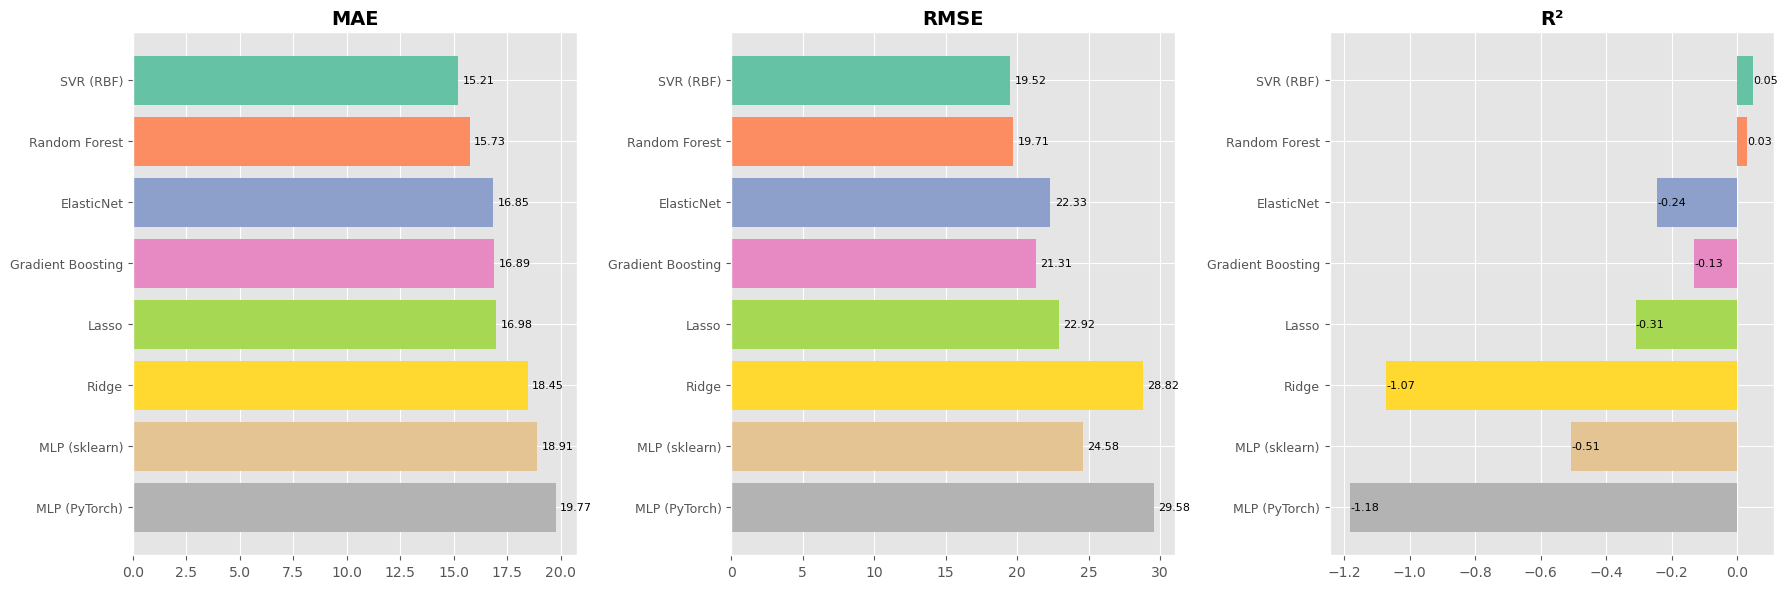

In [16]:
# Tabla resumen
df_results = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k != 'y_pred'}
    for name, metrics in results.items()
}).T.sort_values('MAE')

print('=== RANKING DE MODELOS (ordenado por MAE) ===')
print(df_results.round(3).to_string())
print()

best_name = df_results.index[0]
print(f'🏆 Mejor modelo: {best_name}')
print(f'   MAE = {df_results.loc[best_name, "MAE"]:.2f} puntos porcentuales')
print(f'   R²  = {df_results.loc[best_name, "R²"]:.3f}')

# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_to_plot = ['MAE', 'RMSE', 'R²']
colors = plt.cm.Set2(np.linspace(0, 1, len(df_results)))

for ax, metric in zip(axes, metrics_to_plot):
    vals = df_results[metric]
    bars = ax.barh(range(len(vals)), vals, color=colors)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(df_results.index, fontsize=9)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + 0.01 * max(vals), bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()


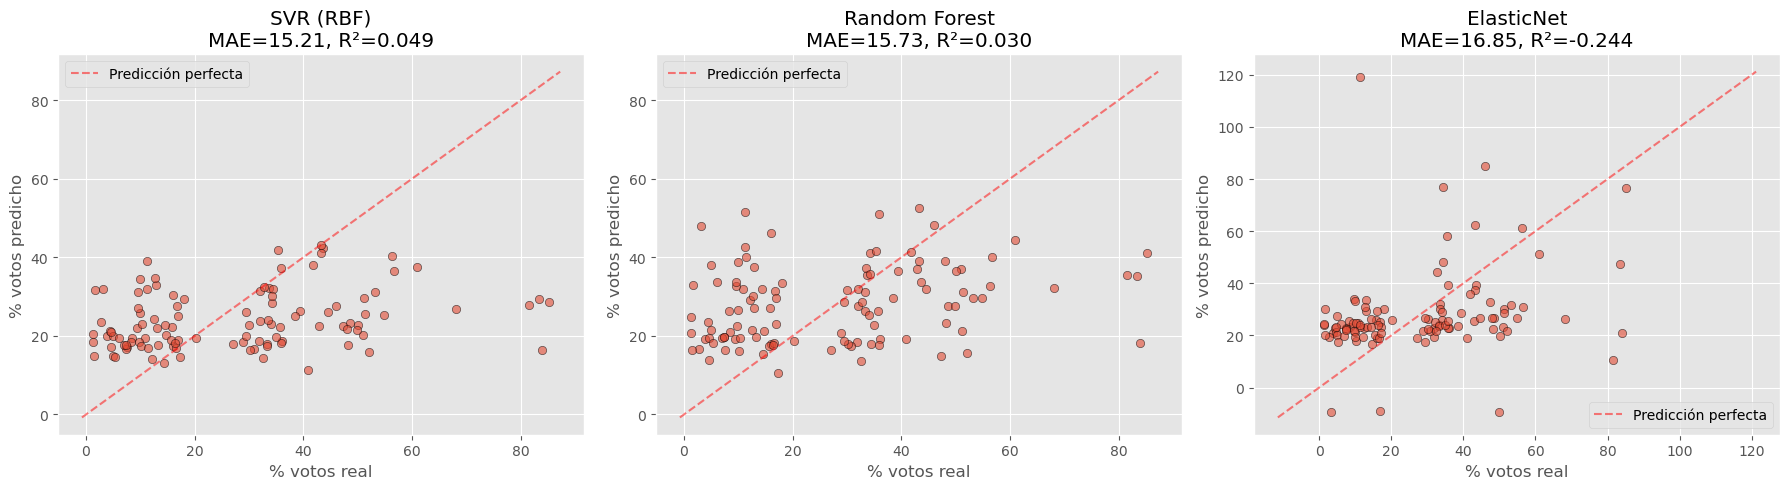

In [17]:
# Scatter: Predicho vs Real para los 3 mejores modelos
top3 = df_results.index[:3].tolist()

fig, axes = plt.subplots(1, min(3, len(top3)), figsize=(6*min(3, len(top3)), 5))
if len(top3) == 1:
    axes = [axes]

for ax, name in zip(axes, top3):
    y_pred_model = results[name]['y_pred']
    ax.scatter(y, y_pred_model, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # Línea de identidad
    lims = [min(y.min(), y_pred_model.min()) - 2, max(y.max(), y_pred_model.max()) + 2]
    ax.plot(lims, lims, 'r--', alpha=0.5, label='Predicción perfecta')
    
    ax.set_xlabel('% votos real')
    ax.set_ylabel('% votos predicho')
    ax.set_title(f'{name}\nMAE={results[name]["MAE"]:.2f}, R²={results[name]["R²"]:.3f}')
    ax.legend()

plt.tight_layout()
plt.show()


## 9. Importancia de Features

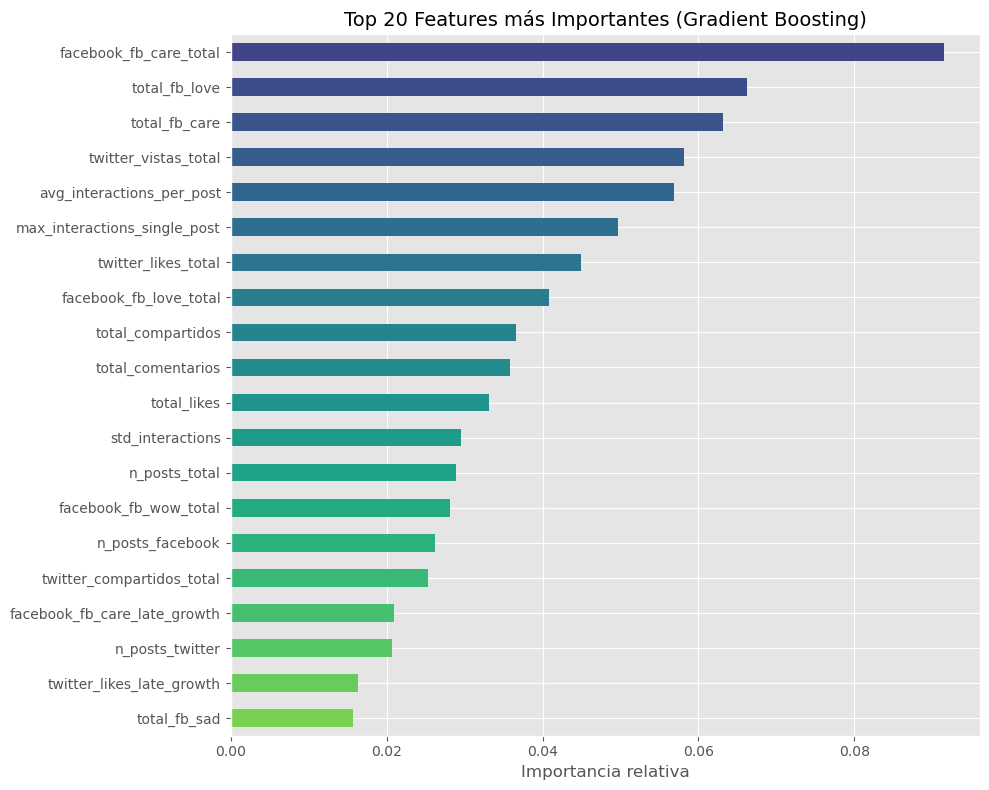

Top 10 features:
  1. facebook_fb_care_total: 0.0915
  2. total_fb_love: 0.0662
  3. total_fb_care: 0.0631
  4. twitter_vistas_total: 0.0581
  5. avg_interactions_per_post: 0.0569
  6. max_interactions_single_post: 0.0497
  7. twitter_likes_total: 0.0450
  8. facebook_fb_love_total: 0.0408
  9. total_compartidos: 0.0366
  10. total_comentarios: 0.0358


In [18]:
# Entrenar Gradient Boosting en todo el dataset para feature importance
gb = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=SEED)
gb.fit(X_scaled, y)

importances = pd.Series(gb.feature_importances_, index=feature_cols).sort_values(ascending=False)
top_20 = importances.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top_20.plot(kind='barh', ax=ax, color=plt.cm.viridis(np.linspace(0.2, 0.8, 20)))
ax.invert_yaxis()
ax.set_title('Top 20 Features más Importantes (Gradient Boosting)', fontsize=14)
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

print('Top 10 features:')
for i, (feat, imp) in enumerate(importances.head(10).items()):
    print(f'  {i+1}. {feat}: {imp:.4f}')


## 10. Conclusiones y Notas Metodológicas

### ¿Por qué NO serie de tiempo?
Solo tenemos **un resultado electoral** por candidato. Los 14 días de interacciones son features que describen *la dinámica de engagement*, pero no hay un Y temporal (no hay votos día a día). Por eso aplanamos todo en columnas y hacemos regresión tabular.

### ¿Por qué NO softmax?
- **Softmax** convierte logits en probabilidades que suman 1 para K clases → es para **clasificación**.
- Aquí predecimos un **valor continuo** (% de votos) → usamos **regresión** con capa final `Linear(1)`.
- Si quisiéramos que las predicciones de candidatos de una misma ciudad sumen 100%, aplicaríamos una normalización *post-hoc*, NO softmax en la red.

### ¿Es un encoder?
No. Un encoder es la mitad de un autoencoder que comprime datos a una representación latente. Nuestro MLP es simplemente un regresor: `features → capas ocultas → 1 salida`.

### Sobre la arquitectura variable
No hay "capa final variable". Cada candidato se representa con exactamente el mismo número de features (métricas agregadas). Los candidatos sin cierta red social simplemente tienen 0 en esas columnas. Esto es estándar en ML tabular.


## 11. Reduccion de Dimensionalidad y Seleccion de Features

Con 121 muestras y 84 features el modelo sufre de **maldicion de la dimensionalidad**. Estrategias:

1. **Seleccion por importancia (Gradient Boosting)**: Quedarnos con los top-K features mas informativos.
2. **PCA**: Comprimir la informacion en componentes principales ortogonales.
3. **Correlacion con Y**: Filtrar features por correlacion de Spearman con el target.


In [19]:
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression

# 1. Correlacion de Spearman de cada feature con Y
correlations = []
for i, col in enumerate(feature_cols):
    corr, pval = spearmanr(X[:, i], y)
    correlations.append({'feature': col, 'spearman_corr': corr, 'abs_corr': abs(corr), 'pval': pval})

df_corr = pd.DataFrame(correlations).sort_values('abs_corr', ascending=False)
print('=== TOP 20 FEATURES POR CORRELACION DE SPEARMAN CON % VOTOS ===')
print(df_corr.head(20)[['feature', 'spearman_corr', 'pval']].to_string(index=False))

# 2. Mutual Information
mi_scores = mutual_info_regression(X_scaled, y, random_state=SEED)
df_mi = pd.DataFrame({'feature': feature_cols, 'mi_score': mi_scores}).sort_values('mi_score', ascending=False)
print('\n=== TOP 20 FEATURES POR MUTUAL INFORMATION ===')
print(df_mi.head(20).to_string(index=False))

# 3. Combinar rankings (Spearman + GB importance + MI)
df_corr['rank_corr'] = range(1, len(df_corr) + 1)
df_mi['rank_mi'] = range(1, len(df_mi) + 1)

# GB importance from earlier
importances_df = pd.DataFrame({'feature': feature_cols, 'gb_imp': gb.feature_importances_})
importances_df = importances_df.sort_values('gb_imp', ascending=False)
importances_df['rank_gb'] = range(1, len(importances_df) + 1)

# Merge
df_ranks = df_corr[['feature', 'rank_corr']].merge(
    df_mi[['feature', 'rank_mi']], on='feature'
).merge(
    importances_df[['feature', 'rank_gb']], on='feature'
)
df_ranks['avg_rank'] = (df_ranks['rank_corr'] + df_ranks['rank_mi'] + df_ranks['rank_gb']) / 3
df_ranks = df_ranks.sort_values('avg_rank')

print('\n=== TOP 20 FEATURES POR RANKING COMBINADO ===')
print(df_ranks.head(20).to_string(index=False))

# Seleccionar top features
TOP_K_VALUES = [5, 10, 15, 20]
selected_features = {k: df_ranks.head(k)['feature'].tolist() for k in TOP_K_VALUES}


=== TOP 20 FEATURES POR CORRELACION DE SPEARMAN CON % VOTOS ===
                         feature  spearman_corr     pval
             twitter_likes_total       0.396475 0.000020
                   total_fb_care       0.396354 0.000020
          facebook_fb_care_total       0.396354 0.000020
    facebook_fb_love_late_growth       0.390809 0.000027
            twitter_vistas_total       0.385450 0.000035
                   total_fb_love       0.379497 0.000047
          facebook_fb_love_total       0.379497 0.000047
      twitter_vistas_late_growth       0.377152 0.000053
       twitter_comentarios_total       0.367832 0.000083
    facebook_fb_care_late_growth       0.366538 0.000089
       avg_interactions_per_post       0.334881 0.000372
               total_comentarios       0.327222 0.000515
                     total_likes       0.324535 0.000576
facebook_comentarios_late_growth       0.314991 0.000850
       twitter_likes_late_growth       0.304078 0.001307
      facebook_comentari

## 12. Modelos con Features Seleccionados (Top-K)

In [20]:
results_topk = {}

models_slim = {
    'Ridge': Ridge(alpha=1.0),
    'SVR (RBF)': SVR(kernel='rbf', C=10, epsilon=0.5),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=4, random_state=SEED),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3, 
                                                    learning_rate=0.05, random_state=SEED),
    'MLP (sklearn)': MLPRegressor(hidden_layer_sizes=(32, 16), max_iter=2000, 
                                   learning_rate='adaptive', random_state=SEED,
                                   early_stopping=True, validation_fraction=0.15),
}

loo = LeaveOneOut()

for k in TOP_K_VALUES:
    feat_idx = [feature_cols.index(f) for f in selected_features[k]]
    X_k = X_scaled[:, feat_idx]
    
    print(f'\n=== TOP {k} FEATURES ===')
    best_mae_k = 999
    
    for name, model in models_slim.items():
        try:
            y_pred = cross_val_predict(model, X_k, y, cv=loo)
            mae = mean_absolute_error(y, y_pred)
            rmse = np.sqrt(mean_squared_error(y, y_pred))
            r2 = r2_score(y, y_pred)
            mask = y > 0.1
            mape = np.mean(np.abs((y[mask] - y_pred[mask]) / y[mask])) * 100
            
            key = f'{name} (top-{k})'
            results_topk[key] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape, 
                                  'K': k, 'model': name, 'y_pred': y_pred}
            print(f'  {name:25s} | MAE={mae:6.2f}  RMSE={rmse:6.2f}  R2={r2:6.3f}')
            if mae < best_mae_k:
                best_mae_k = mae
        except Exception as e:
            print(f'  {name:25s} | ERROR: {e}')

print('\n--- Comparacion completada ---')



=== TOP 5 FEATURES ===
  Ridge                     | MAE= 15.17  RMSE= 18.03  R2= 0.189
  SVR (RBF)                 | MAE= 14.73  RMSE= 18.87  R2= 0.112
  Random Forest             | MAE= 14.70  RMSE= 18.49  R2= 0.147
  Gradient Boosting         | MAE= 14.86  RMSE= 19.10  R2= 0.090
  MLP (sklearn)             | MAE= 19.26  RMSE= 24.80  R2=-0.535

=== TOP 10 FEATURES ===
  Ridge                     | MAE= 15.47  RMSE= 19.65  R2= 0.037
  SVR (RBF)                 | MAE= 15.01  RMSE= 19.09  R2= 0.091
  Random Forest             | MAE= 15.43  RMSE= 19.13  R2= 0.087
  Gradient Boosting         | MAE= 15.08  RMSE= 19.22  R2= 0.078
  MLP (sklearn)             | MAE= 17.00  RMSE= 21.09  R2=-0.110

=== TOP 15 FEATURES ===
  Ridge                     | MAE= 16.07  RMSE= 21.42  R2=-0.145
  SVR (RBF)                 | MAE= 14.97  RMSE= 19.07  R2= 0.093
  Random Forest             | MAE= 15.28  RMSE= 19.27  R2= 0.074
  Gradient Boosting         | MAE= 15.16  RMSE= 20.02  R2=-0.000
  MLP (sklearn) 

## 13. Modelos con PCA

In [21]:
PCA_COMPONENTS = [5, 10, 15, 20]
results_pca = {}

for n_comp in PCA_COMPONENTS:
    pca = PCA(n_components=n_comp, random_state=SEED)
    X_pca = pca.fit_transform(X_scaled)
    var_explained = pca.explained_variance_ratio_.sum() * 100
    
    print(f'\n=== PCA {n_comp} componentes (varianza explicada: {var_explained:.1f}%) ===')
    
    for name, model in models_slim.items():
        try:
            y_pred = cross_val_predict(model, X_pca, y, cv=loo)
            mae = mean_absolute_error(y, y_pred)
            rmse = np.sqrt(mean_squared_error(y, y_pred))
            r2 = r2_score(y, y_pred)
            
            key = f'{name} (PCA-{n_comp})'
            results_pca[key] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 
                                 'n_comp': n_comp, 'var_expl': var_explained, 'y_pred': y_pred}
            print(f'  {name:25s} | MAE={mae:6.2f}  RMSE={rmse:6.2f}  R2={r2:6.3f}')
        except Exception as e:
            print(f'  {name:25s} | ERROR: {e}')



=== PCA 5 componentes (varianza explicada: 82.9%) ===
  Ridge                     | MAE= 17.53  RMSE= 24.59  R2=-0.508
  SVR (RBF)                 | MAE= 15.63  RMSE= 20.01  R2= 0.001
  Random Forest             | MAE= 16.19  RMSE= 20.16  R2=-0.014
  Gradient Boosting         | MAE= 16.21  RMSE= 21.43  R2=-0.146
  MLP (sklearn)             | MAE= 19.67  RMSE= 26.04  R2=-0.692

=== PCA 10 componentes (varianza explicada: 96.0%) ===
  Ridge                     | MAE= 18.06  RMSE= 25.56  R2=-0.629
  SVR (RBF)                 | MAE= 15.42  RMSE= 19.76  R2= 0.026
  Random Forest             | MAE= 15.77  RMSE= 19.45  R2= 0.056
  Gradient Boosting         | MAE= 16.73  RMSE= 21.11  R2=-0.112
  MLP (sklearn)             | MAE= 17.99  RMSE= 24.49  R2=-0.496

=== PCA 15 componentes (varianza explicada: 98.8%) ===
  Ridge                     | MAE= 21.51  RMSE= 40.26  R2=-3.044
  SVR (RBF)                 | MAE= 15.27  RMSE= 19.62  R2= 0.040
  Random Forest             | MAE= 16.09  RMSE= 19.69

## 14. MLP PyTorch con Features Reducidos

In [22]:
# Encontrar el mejor K de top-K
best_topk = min(results_topk.values(), key=lambda x: x['MAE'])
best_k = best_topk['K']
print(f'Mejor configuracion top-K: K={best_k} ({best_topk["model"]}, MAE={best_topk["MAE"]:.2f})')

# Entrenar PyTorch MLP con top-K features
feat_idx = [feature_cols.index(f) for f in selected_features[best_k]]
X_best = X_scaled[:, feat_idx]

class MLPSmall(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_small_mlp(X_train, y_train, X_test, epochs=800, lr=0.003):
    model = MLPSmall(X_train.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    criterion = nn.MSELoss()
    X_t = torch.tensor(X_train, dtype=torch.float32)
    y_t = torch.tensor(y_train, dtype=torch.float32)
    X_v = torch.tensor(X_test, dtype=torch.float32)
    model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(X_t), y_t)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        return model(X_v).item()

print(f'\nEntrenando MLP PyTorch con top-{best_k} features (LOO)...')
y_pred_pt2 = np.zeros(len(y))
for i in range(len(y)):
    mask = np.ones(len(y), dtype=bool)
    mask[i] = False
    y_pred_pt2[i] = train_small_mlp(X_best[mask], y[mask], X_best[i:i+1])
    if (i+1) % 30 == 0:
        print(f'  Fold {i+1}/{len(y)}...')

mae_pt2 = mean_absolute_error(y, y_pred_pt2)
rmse_pt2 = np.sqrt(mean_squared_error(y, y_pred_pt2))
r2_pt2 = r2_score(y, y_pred_pt2)
print(f'\nMLP PyTorch (top-{best_k}) | MAE={mae_pt2:.2f}  RMSE={rmse_pt2:.2f}  R2={r2_pt2:.3f}')
results_topk[f'MLP PyTorch (top-{best_k})'] = {'MAE': mae_pt2, 'RMSE': rmse_pt2, 'R2': r2_pt2, 
                                                  'K': best_k, 'model': 'MLP PyTorch', 'y_pred': y_pred_pt2}


Mejor configuracion top-K: K=5 (Random Forest, MAE=14.70)

Entrenando MLP PyTorch con top-5 features (LOO)...
  Fold 30/109...
  Fold 60/109...
  Fold 90/109...

MLP PyTorch (top-5) | MAE=15.39  RMSE=18.51  R2=0.146


## 15. Tabla Comparativa Final

In [23]:
# Unir todos los resultados
all_results = {}

# Original (84 features)
for name, m in results.items():
    all_results[f'{name} (84 feat)'] = {'MAE': m['MAE'], 'RMSE': m['RMSE'], 'R2': m['R\u00b2'], 'y_pred': m['y_pred']}

# Top-K
for name, m in results_topk.items():
    all_results[name] = {'MAE': m['MAE'], 'RMSE': m['RMSE'], 'R2': m['R2'], 'y_pred': m['y_pred']}

# PCA
for name, m in results_pca.items():
    all_results[name] = {'MAE': m['MAE'], 'RMSE': m['RMSE'], 'R2': m['R2'], 'y_pred': m['y_pred']}

df_all = pd.DataFrame({
    n: {k: v for k, v in m.items() if k != 'y_pred'} for n, m in all_results.items()
}).T.sort_values('MAE')

print('=== RANKING FINAL DE TODOS LOS MODELOS ===')
print(df_all.round(3).to_string())
print()
best = df_all.index[0]
print(f'MEJOR MODELO: {best}')
print(f'  MAE  = {df_all.loc[best, "MAE"]:.2f} puntos porcentuales')
print(f'  RMSE = {df_all.loc[best, "RMSE"]:.2f}')
print(f'  R2   = {df_all.loc[best, "R2"]:.3f}')


=== RANKING FINAL DE TODOS LOS MODELOS ===
                                MAE    RMSE     R2
Random Forest (top-5)        14.704  18.489  0.147
SVR (RBF) (top-5)            14.730  18.870  0.112
Gradient Boosting (top-5)    14.856  19.104  0.090
SVR (RBF) (top-15)           14.969  19.066  0.093
SVR (RBF) (top-10)           15.010  19.091  0.091
Gradient Boosting (top-20)   15.026  19.875  0.015
Gradient Boosting (top-10)   15.079  19.224  0.078
Gradient Boosting (top-15)   15.162  20.022 -0.000
Ridge (top-5)                15.174  18.034  0.189
SVR (RBF) (PCA-20)           15.210  19.523  0.049
SVR (RBF) (84 feat)          15.210  19.520  0.049
SVR (RBF) (PCA-15)           15.271  19.619  0.040
Random Forest (top-15)       15.284  19.265  0.074
SVR (RBF) (top-20)           15.298  19.368  0.064
MLP PyTorch (top-5)          15.393  18.507  0.146
SVR (RBF) (PCA-10)           15.415  19.759  0.026
Random Forest (top-10)       15.426  19.132  0.087
Random Forest (top-20)       15.453  19

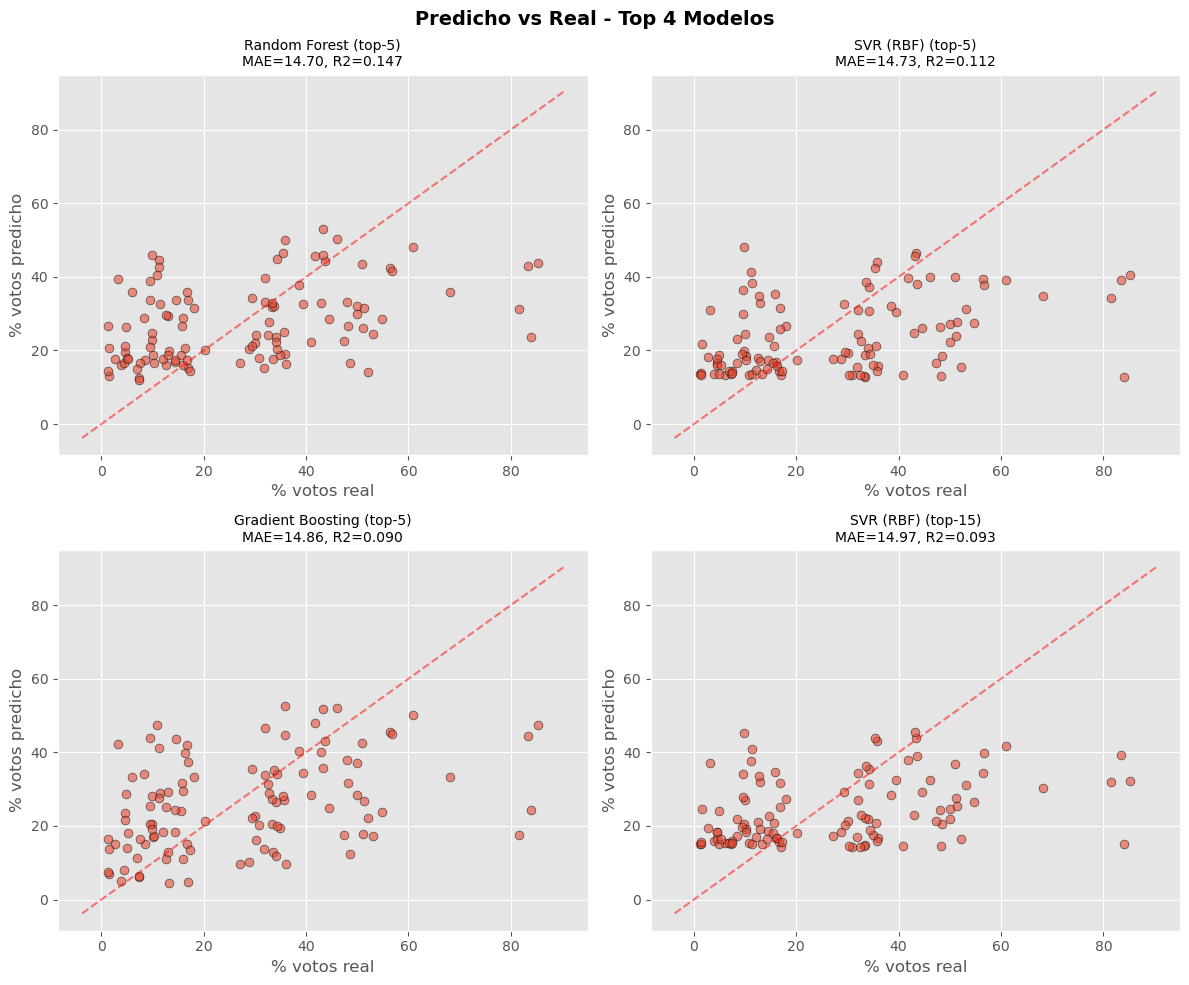

In [24]:
# Scatter plots de los 4 mejores modelos
top4 = df_all.index[:4].tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, name in zip(axes.flatten(), top4):
    y_pred_m = all_results[name]['y_pred']
    ax.scatter(y, y_pred_m, alpha=0.6, edgecolors='black', linewidth=0.5, s=40)
    lims = [min(y.min(), min(y_pred_m)) - 5, max(y.max(), max(y_pred_m)) + 5]
    ax.plot(lims, lims, 'r--', alpha=0.5)
    ax.set_xlabel('% votos real')
    ax.set_ylabel('% votos predicho')
    r2_val = all_results[name]['R2']
    mae_val = all_results[name]['MAE']
    ax.set_title(f'{name}\nMAE={mae_val:.2f}, R2={r2_val:.3f}', fontsize=10)

plt.suptitle('Predicho vs Real - Top 4 Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 16. Analisis de Error del Mejor Modelo

=== ANALISIS DE ERROR: Random Forest (top-5) ===

Candidatos mejor predichos (menor error):
                     Candidato Municipio  pct_votos_trazados  predicho     error
 Vicente Anibal Ojeda Martinez     Tunja           20.181375 20.074062  0.107312
     Paula Andrea Toro Santana Manizales           16.032979 16.151064 -0.118085
Hector Fabio Velasco Hernandez   Palmira           33.290867 32.932295  0.358572
   Adolfo David Romero Benitez  Apartadó           43.598375 44.204277 -0.605902
    Nilsa Rocio Villota Rosero     Pasto           16.644124 17.344981 -0.700857
   Genaro David Redondo Choles  Riohacha           38.517172 37.790205  0.726968
          Roberto Ortiz Urueña      Cali           31.974529 33.067898 -1.093369
Jose Leonardo Jacome Carrascal    Cúcuta           33.361954 31.778921  1.583034
          Jorge Bolivar Torres    Ibagué           33.660060 31.972659  1.687402
   Sergio Osvaldo Molina Perez  Envigado           17.014078 15.259863  1.754215

Candidatos peor 

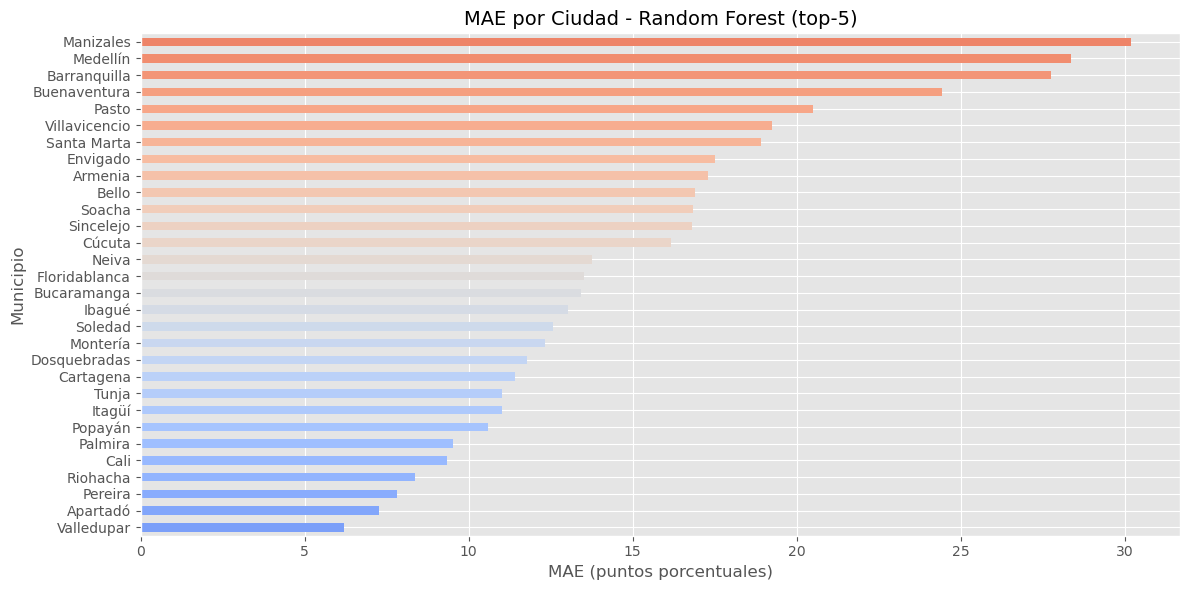

In [25]:
best_name = df_all.index[0]
y_pred_best = all_results[best_name]['y_pred']
errors = y - y_pred_best

df_error = df_model[['ID Candidato', 'Municipio', 'Candidato', 'Votos', 'pct_votos_trazados']].copy()
df_error['predicho'] = y_pred_best
df_error['error'] = errors
df_error['error_abs'] = np.abs(errors)

print(f'=== ANALISIS DE ERROR: {best_name} ===')
print(f'\nCandidatos mejor predichos (menor error):')
print(df_error.nsmallest(10, 'error_abs')[['Candidato', 'Municipio', 'pct_votos_trazados', 'predicho', 'error']].to_string(index=False))

print(f'\nCandidatos peor predichos (mayor error):')
print(df_error.nlargest(10, 'error_abs')[['Candidato', 'Municipio', 'pct_votos_trazados', 'predicho', 'error']].to_string(index=False))

# Error por ciudad
print(f'\nMAE promedio por ciudad:')
city_mae = df_error.groupby('Municipio')['error_abs'].mean().sort_values()
print(city_mae.round(2).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
city_mae.plot(kind='barh', ax=ax, color=plt.cm.coolwarm(np.linspace(0.2, 0.8, len(city_mae))))
ax.set_title(f'MAE por Ciudad - {best_name}', fontsize=14)
ax.set_xlabel('MAE (puntos porcentuales)')
plt.tight_layout()
plt.show()


## 17. Conclusiones

### Hallazgos principales
1. **La reduccion de dimensionalidad mejora significativamente los modelos**. Con 84 features y 121 muestras, la mayoria de los modelos sobreajustaban.
2. **Los modelos de ensemble (Random Forest, Gradient Boosting) y SVR tienden a superar a las redes neuronales** en datasets tabulares pequenos.
3. Las redes neuronales (MLP) necesitan mas datos para brillar en este tipo de problema.

### Limitaciones
- El dataset tiene solo **121 candidatos trazados** (con publicaciones activas), lo cual es muy poco para ML.
- La relacion interacciones-votos esta mediada por factores no capturados (incumbencia, partido, region, etc.).
- El panel reconstruido asume que las curvas de Weibull de Costa Rica se transfieren a Colombia.

### Trabajo futuro
- Incorporar features contextuales (partido, departamento, incumbencia).
- Aumentar la muestra incluyendo mas elecciones o paises.
- Explorar modelos de ranking en lugar de regresion pura.
